# EDA

## Daten laden
europe-electricity-load-hourly-20192025 aus Kaggle manuell herunterladen und als csv einlesen

In [ ]:
!pip install kagglehub

In [2]:
# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

In [ ]:
import kagglehub
import shutil
import os

dataset_link = "dsersun/europe-electricity-load-hourly-20192025"  # just the owner/dataset part
destination = "../data/raw"

cache_path = kagglehub.dataset_download(dataset_link)
#print(f"Downloaded to cache: {cache_path}")

os.makedirs(destination, exist_ok=True)

# Copy all files from cache to destination
for file in os.listdir(cache_path):
    shutil.copy(os.path.join(cache_path, file), destination)
    print(f"Copied: {file} → {destination}")

In [8]:
import pandas as pd

# Load the dataset
file_path = "../data/raw/MHLV_2019_2025_combined.csv"
df_energy = pd.read_csv(file_path, parse_dates=['DateUTC', 'DateShort'])

In [5]:
display(df_energy.head())
print(df_energy.info())
print(df_energy.describe())

,MeasureItem,DateUTC,DateShort,TimeFrom,TimeTo,CountryCode,Cov_ratio,Value,Value_ScaleTo100,year
0,Monthly Hourly Load Values,2019-01-01 00:00:00,2019-01-01,1970-01-01 00:00:00,1970-01-01 01:00:00,AT,100,5852.5,5852.5,2019
1,Monthly Hourly Load Values,2019-01-01 01:00:00,2019-01-01,1970-01-01 01:00:00,1970-01-01 02:00:00,AT,100,5619.2,5619.2,2019
2,Monthly Hourly Load Values,2019-01-01 02:00:00,2019-01-01,1970-01-01 02:00:00,1970-01-01 03:00:00,AT,100,5323.9,5323.9,2019
3,Monthly Hourly Load Values,2019-01-01 03:00:00,2019-01-01,1970-01-01 03:00:00,1970-01-01 04:00:00,AT,100,5273.3,5273.3,2019
4,Monthly Hourly Load Values,2019-01-01 04:00:00,2019-01-01,1970-01-01 04:00:00,1970-01-01 05:00:00,AT,100,5439.0,5439.0,2019


<class 'pandas.DataFrame'>
RangeIndex: 2071728 entries, 0 to 2071727
Data columns (total 10 columns):
 #   Column            Dtype         
---  ------            -----         
 0   MeasureItem       str           
 1   DateUTC           datetime64[us]
 2   DateShort         datetime64[us]
 3   TimeFrom          str           
 4   TimeTo            str           
 5   CountryCode       str           
 6   Cov_ratio         int64         
 7   Value             float64       
 8   Value_ScaleTo100  float64       
 9   year              int64         
dtypes: datetime64[us](2), float64(2), int64(2), str(4)
memory usage: 282.0 MB
None
                          DateUTC                   DateShort  Cov_ratio  \
count                     2071728                     2071728  2071728.0   
mean   2022-05-31 21:57:29.807117  2022-05-31 10:27:35.369430      100.0   
min           2019-01-01 00:00:00         2019-01-01 00:00:00      100.0   
25%           2020-09-23 12:00:00         2020-09-23 0

In [ ]:
df_energy = df_energy.drop(['DateShort', 'MeasureItem', 'TimeFrom', 'TimeTo', 'Cov_ratio', 'Value_ScaleTo100'], axis=1)
df_energy = df_energy.rename(columns={'Value': 'EnergyDemand'})
df_energy = df_energy[df_energy['CountryCode'] == 'DE']
df_energy = df_energy.drop('CountryCode', axis=1)


In [10]:
df_energy['hour'] = df_energy['DateUTC'].dt.hour
df_energy['weekday'] = df_energy['DateUTC'].dt.dayofweek
df_energy['month'] = df_energy['DateUTC'].dt.month
df_energy['is_weekend'] = (df_energy['DateUTC'].dt.weekday >= 5).astype(int)

In [2]:
%pip install holidays

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# add public holidays for Germany
import pandas as pd
import holidays 

de_holidays = holidays.Germany(years=range(2019, 2026))
df_energy['is_holiday'] = df_energy['DateUTC'].dt.date.apply(lambda x: 1 if x in de_holidays else 0)

# add holiday ratio depending the number of states in Germany with a holiday on that day
def holiday_ratio(date):
    count = sum([1 for state in holidays.Germany(years=[date.year]).items() if state[0] == date])
    return count / 16   
df_energy['holiday_ratio'] = df_energy['DateUTC'].dt.date.apply(holiday_ratio)

In [15]:
df_energy.to_csv("../data/energy_demand_de_2019_2025.csv", index=False)

In [16]:
df_energy.describe()

,DateUTC,EnergyDemand,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio
count,59160,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000
mean,2022-05-17 11:30:00.365111,54663.227387,2021.888032,11.500101,2.999189,6.355375,0.285598,0.024341,0.001521
min,2019-01-01 00:00:00,30908.880000,2019.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2020-09-08 05:45:00,46803.277500,2020.000000,5.750000,1.000000,3.000000,0.000000,0.000000,0.000000
50%,2022-05-17 11:30:00,54517.358750,2022.000000,11.500000,3.000000,6.000000,0.000000,0.000000,0.000000
75%,2024-01-23 17:15:00,62177.330000,2024.000000,17.250000,5.000000,9.000000,1.000000,0.000000,0.000000
max,2025-09-30 23:00:00,81077.455000,2025.000000,23.000000,6.000000,12.000000,1.000000,1.000000,0.062500
std,NaN,9666.896304,1.949594,6.922113,2.000017,3.396644,0.451703,0.154106,0.009632


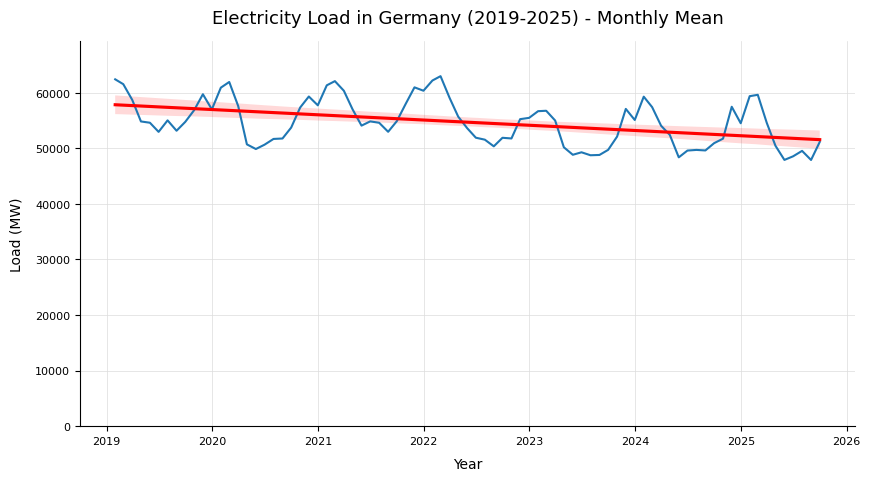

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd   

df_energy = pd.read_csv("../data/energy_demand_de_2019_2025.csv", parse_dates=['DateUTC'])

df_monthly = df_energy.set_index('DateUTC')['EnergyDemand'].resample('ME').mean().reset_index()

# Convert dates to float for regression
df_monthly['DateNum'] = mdates.date2num(df_monthly['DateUTC'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_monthly, x='DateUTC', y='EnergyDemand', ax=ax)
plt.title('Electricity Load in Germany (2019-2025) - Monthly Mean')

# add trend line
sns.regplot(data=df_monthly, x='DateNum', y='EnergyDemand',
            scatter=False, color='red', label='Trend Line', ax=ax)

plt.ylim(0, df_monthly['EnergyDemand'].max() * 1.1)
plt.xlabel('Year')
plt.ylabel('Load (MW)')
plt.show()

## time series decomposition

* additive model - seasonal values and redisual independent on trend

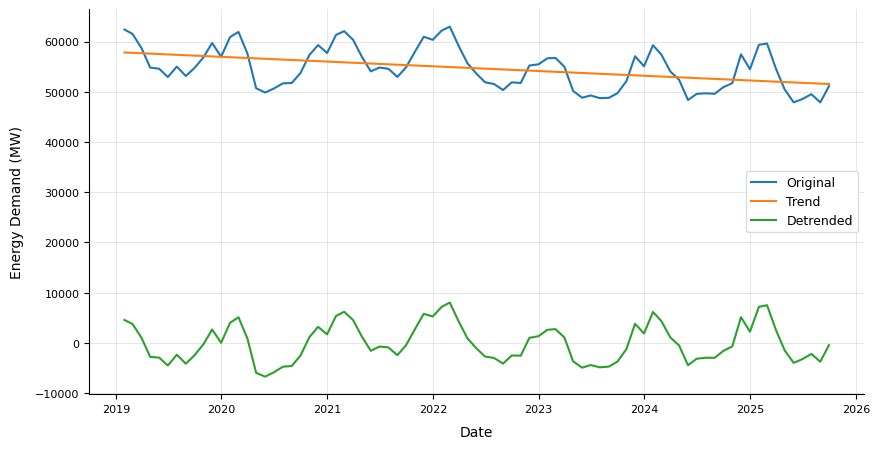

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_energy_de = pd.read_csv("../data/energy_demand_de_2019_2025.csv", parse_dates=['DateUTC'])
df_monthly = df_energy_de.set_index('DateUTC')['EnergyDemand'].resample('ME').mean().reset_index()
df_monthly.set_index('DateUTC', inplace=True)
# Convert dates to float for regression
df_monthly['DateNum'] = mdates.date2num(df_monthly.index)

slope, intercept = np.polyfit(df_monthly['DateNum'], df_monthly['EnergyDemand'], 1) # estimate line coefficient
trend = df_monthly['DateNum'] * slope + intercept # linear trend
detrended = df_monthly['EnergyDemand'] - trend # remove the trend

plt.figure(figsize=(10, 5))
plt.plot(df_monthly['EnergyDemand'], label='Original')
plt.plot(trend, label='Trend')
plt.plot(detrended, label='Detrended')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Energy Demand (MW)')
plt.show()

In [ ]:
!pip install statsmodels

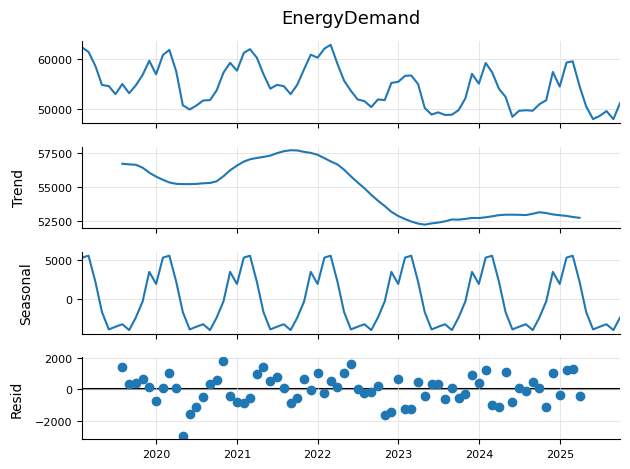

In [22]:
# decompose seasonality using seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose     
#df_monthly.set_index('DateUTC', inplace=True)
decomposition = seasonal_decompose(df_monthly['EnergyDemand'], model='additive', period=12) # monthly data, so period is 12 months
decomposition.plot();  # use ; to avoid doubled plot. the returned figure is already plotted by the function, so we just suppress the output to avoid a second empty plot.

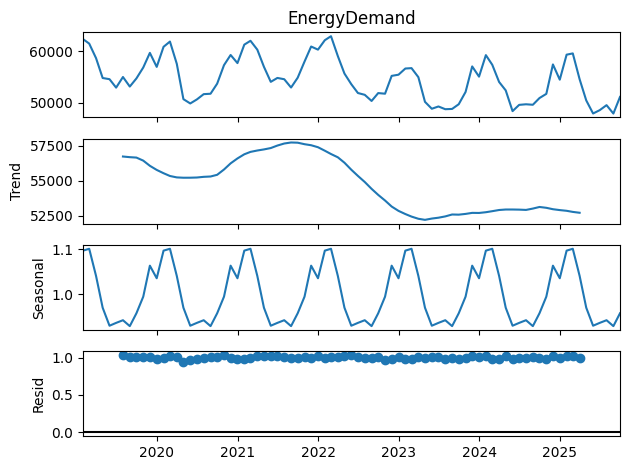

In [ ]:
# decompose seasonality using seasonal_decompose with multiplicative model
from statsmodels.tsa.seasonal import seasonal_decompose     
#df_monthly.set_index('DateUTC', inplace=True)
decomposition = seasonal_decompose(df_monthly['EnergyDemand'], model='multiplicative', period=12) # monthly data, so period is 12 months
decomposition.plot();  # use ; to avoid doubled plot. the returned figure is already plotted by the function, so we just suppress the output to avoid a second empty plot.

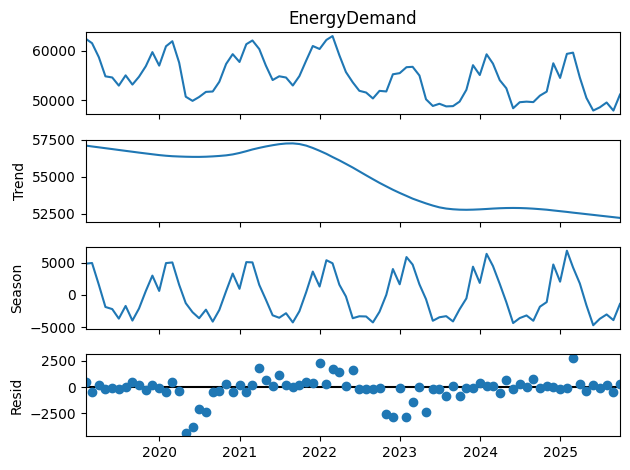

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from scipy.fft import fft
np.random.seed(0)  # for reproducibility

stl_decomposition = STL(endog=df_monthly['EnergyDemand'], period=12, robust=True).fit()
stl_decomposition.plot();  # use ; to avoid doubled plot. the returned figure is already plotted by the function, so we just suppress the output to avoid a second empty plot.